In [5]:
import sys
sys.path.insert(0, '../..')
import math
import numpy as np
import matplotlib.pyplot as plt 
import mssfp
import deepssfp
from deepssfp import dataloader, view, recon, dataformatter, deepssfp, models, plotlib

In [6]:
import tensorflow as tf

# Check if TensorFlow can see any GPUs
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Get detailed information about available GPUs
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    print("Name:", gpu.name, "Type:", gpu.device_type)

Num GPUs Available:  1
Name: /physical_device:GPU:0 Type: GPU


Generating phantom...
Generating 3D phantom: (120, 434, 362)
Generating SSFP dataset...


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:64: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:91: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Dataset complete.
Dataset shape: (120, 128, 128, 4)


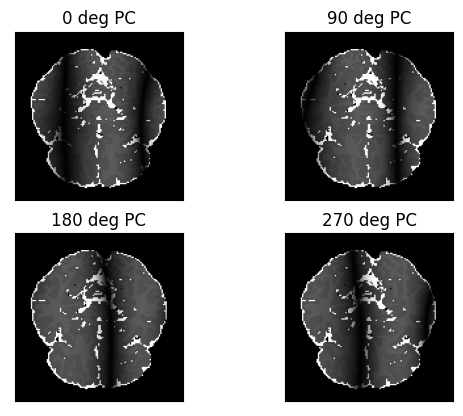

In [7]:
dataset = mssfp.generate_ssfp_dataset(phantom_type='brain', shape=128, npcs=4, f=500, alpha=np.deg2rad(60), sigma=0.0001, data_indices=[(0, 2), (120,180)], useRotate=True, useDeform=True)
data = dataset['M']
fieldmap = dataset['fieldmap']
T1 = dataset['t1']
T2 = dataset['t2']
data.shape
mssfp.plot_dataset(data, slice=0)

In [8]:
mode = 'BandRemoval:2'
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)

(96, 128, 128, 4) (96, 128, 128, 2)


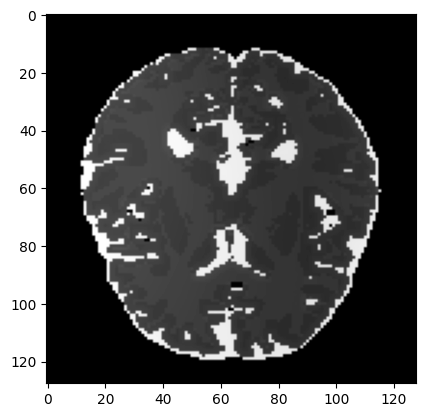

In [9]:
plt.figure()
plt.subplot(1,1,1)
plt.imshow(np.abs(ds.x_train[0,:,:,0] + 1j * ds.x_train[0,:,:,1]))
plt.subplot(1,1,1)
plt.imshow(np.abs(ds.y_train[0,:,:,0] + 1j * ds.y_train[0,:,:,1]))
plt.show()


In [10]:
mode = 'BandRemoval:2'
with tf.device('/GPU:0'):
    model, history, ds, predictions = deepssfp.train(mode, epochs=400, dataset=ds, model_path="D:/DeepSSFP/SavedModels")

Training DataSet: (96, 128, 128, 4) (96, 128, 128, 2)
Test DataSet: (24, 128, 128, 4) (24, 128, 128, 2)
DL Model: 128, 128, 4, 2
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 4) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128        

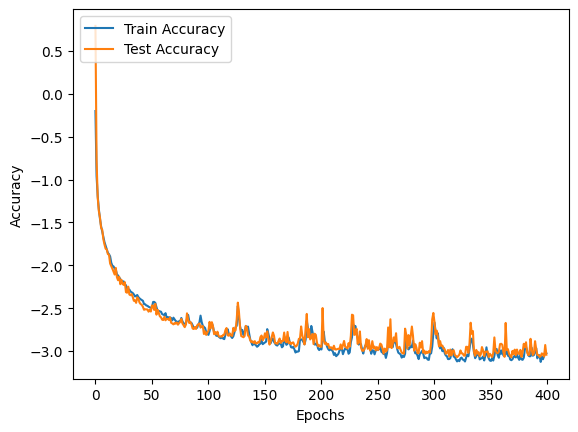

In [11]:
plotlib.plot_model_history(history)

In [12]:
ds.x_test.shape, ds.y_test.shape, predictions.shape

((24, 128, 128, 4), (24, 128, 128, 2), (24, 128, 128, 2))

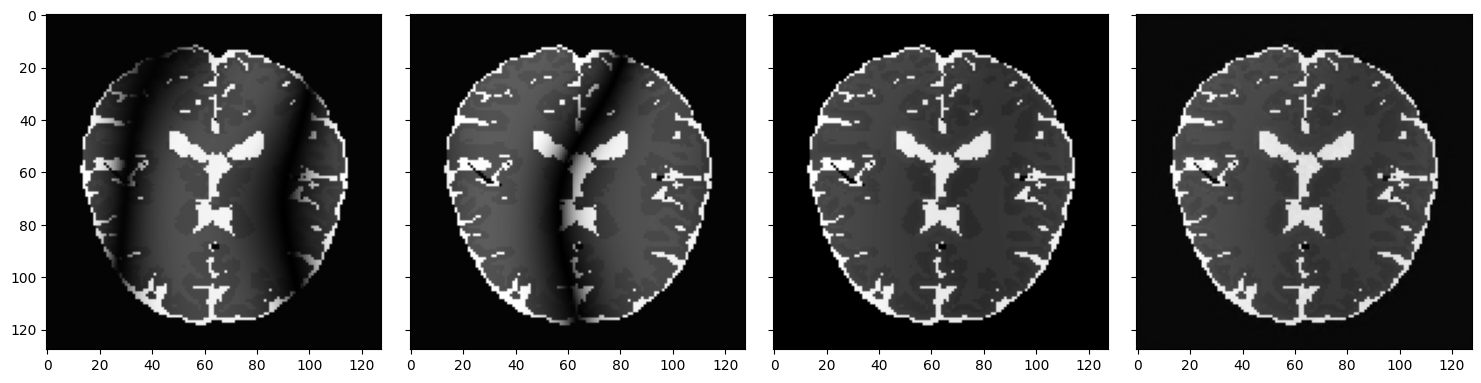

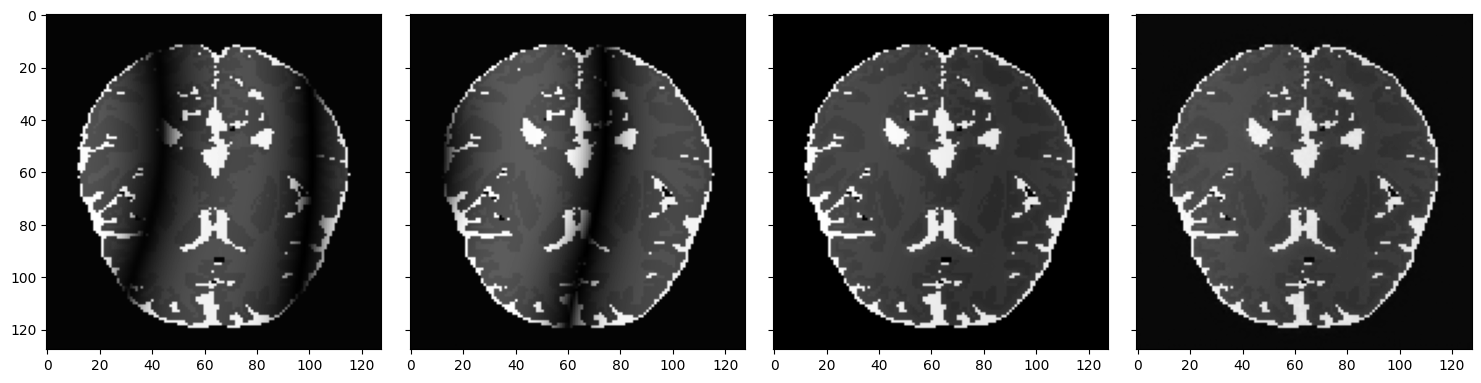

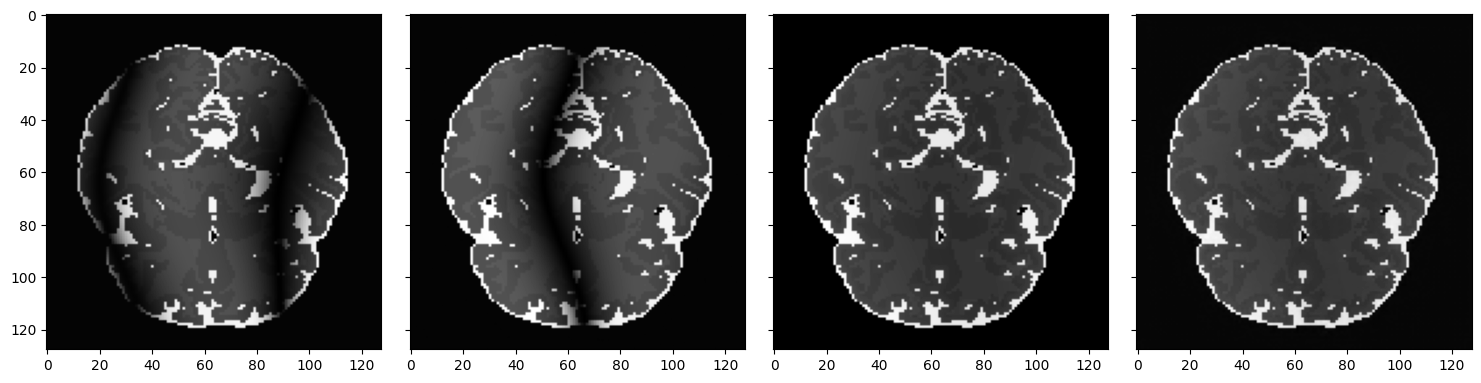

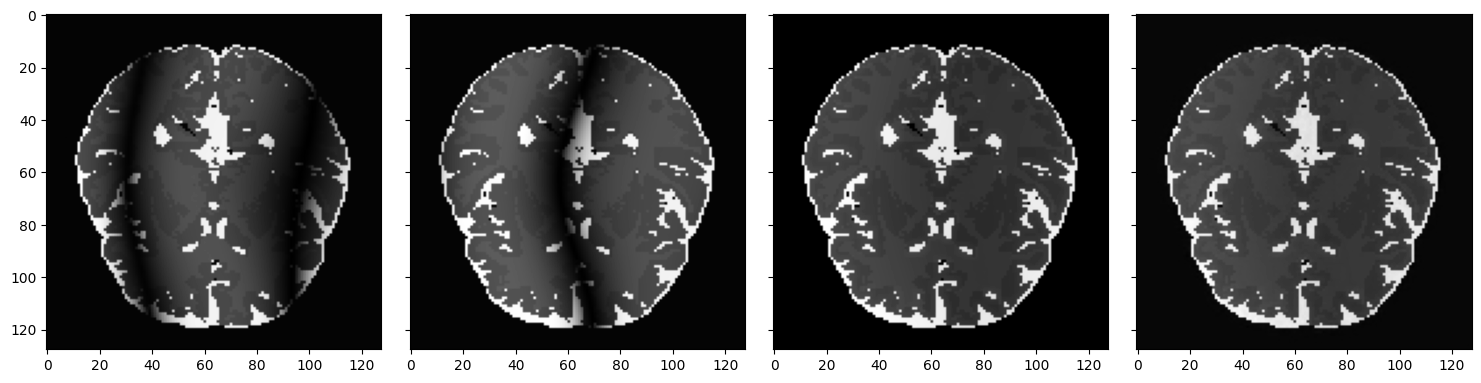

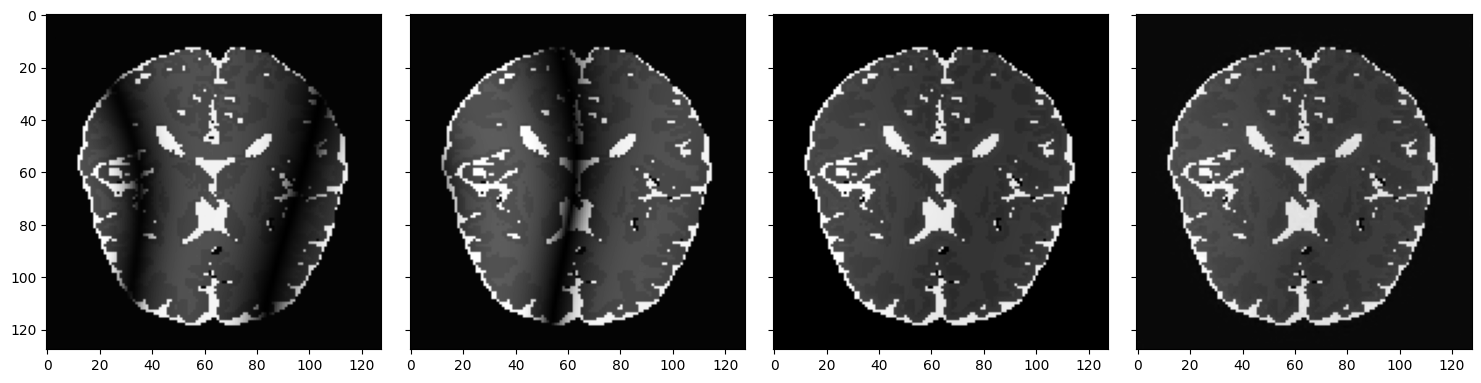

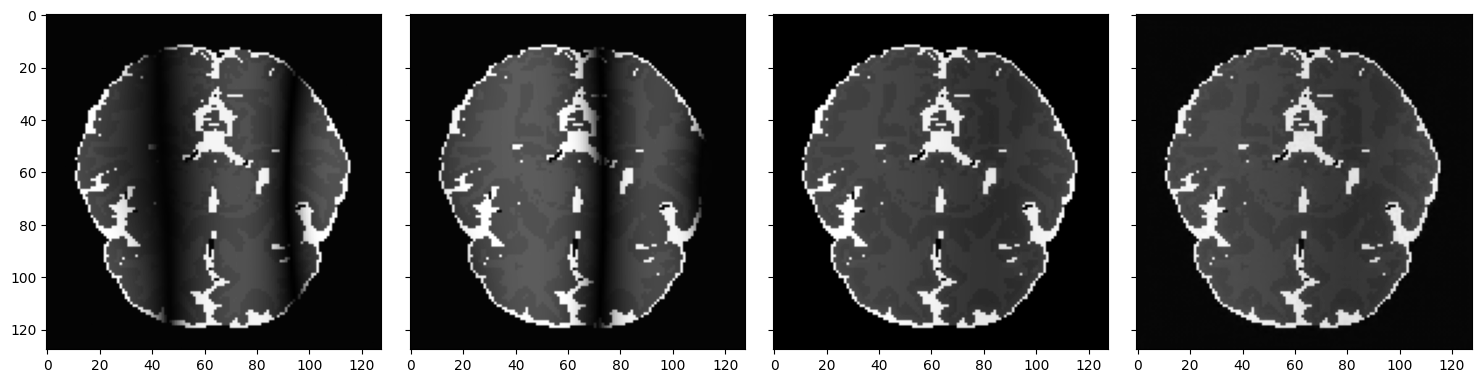

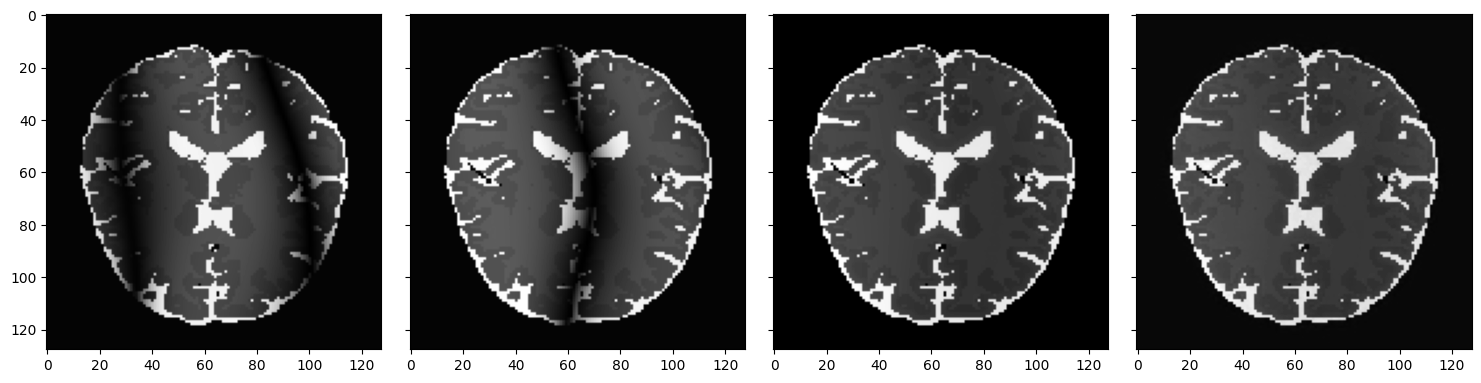

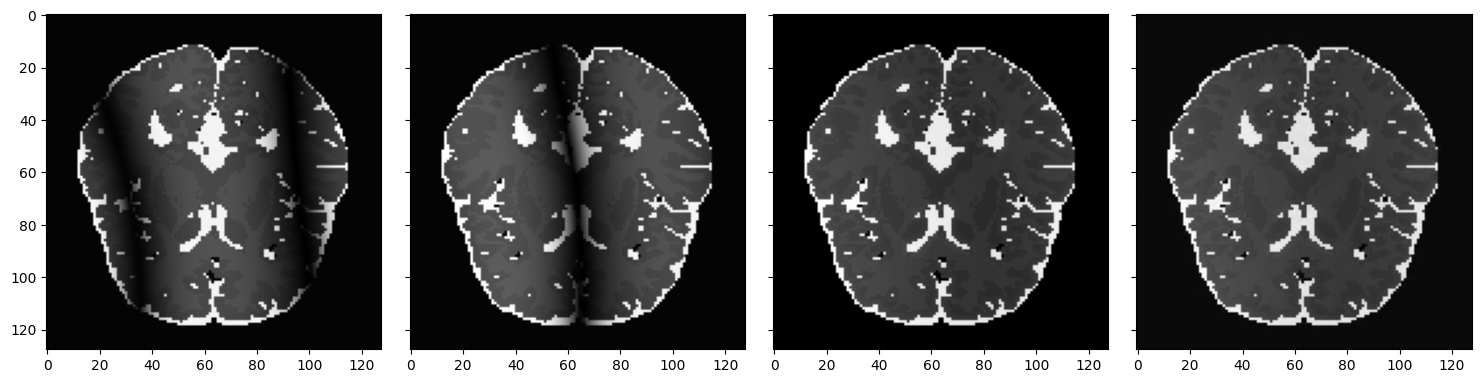

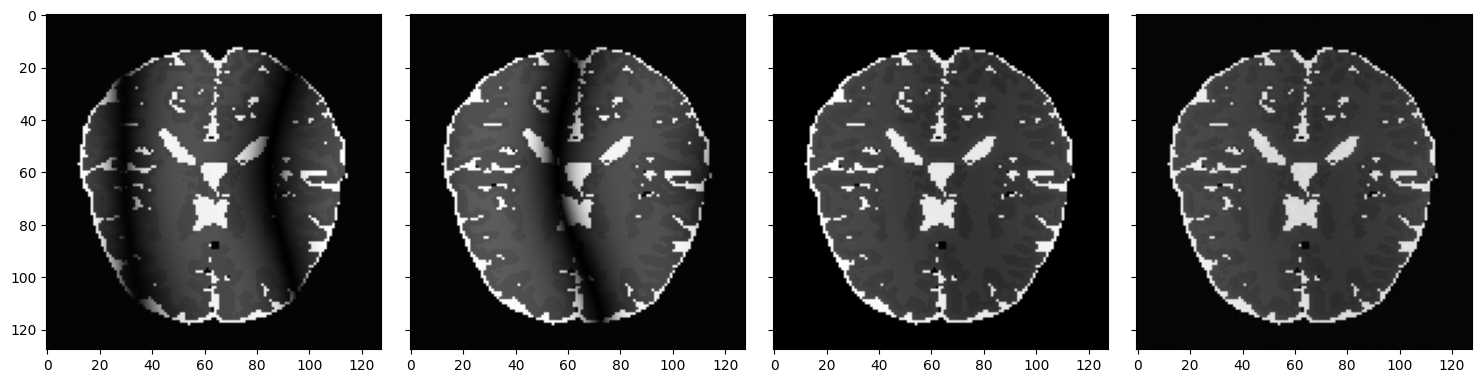

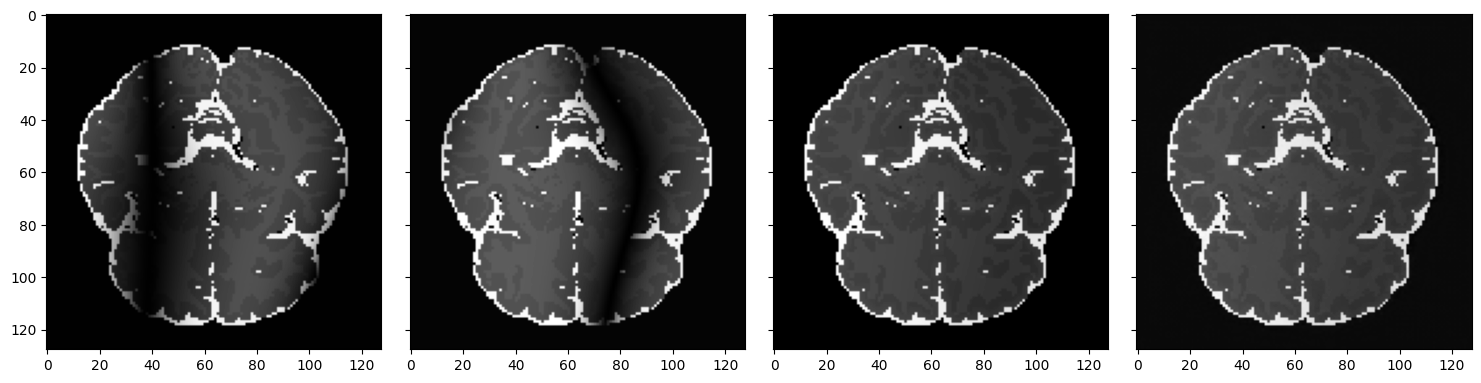

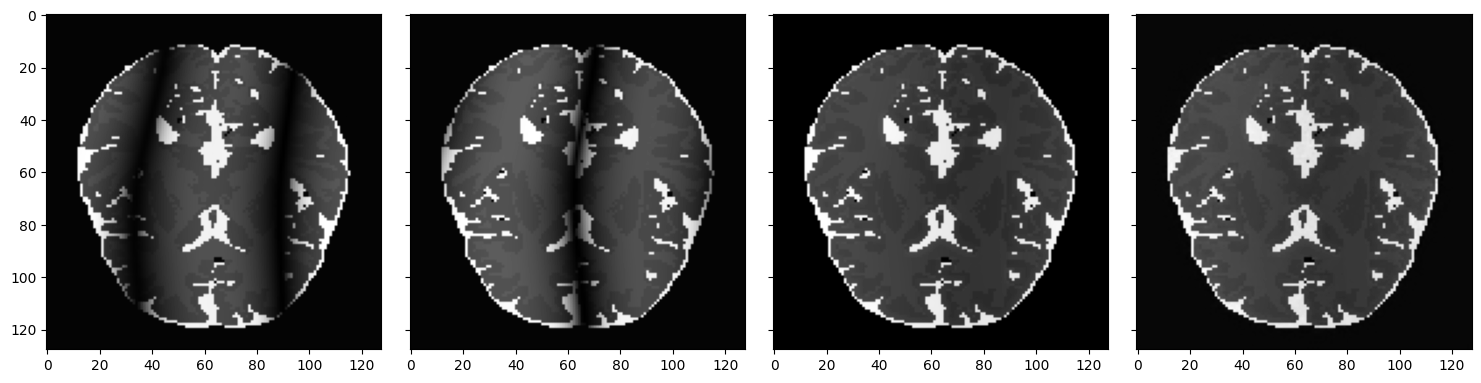

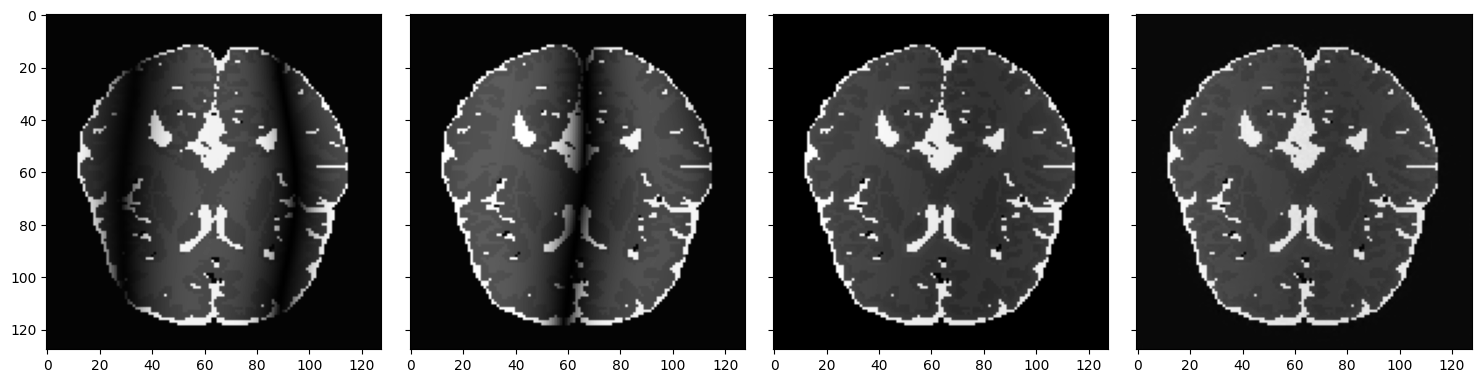

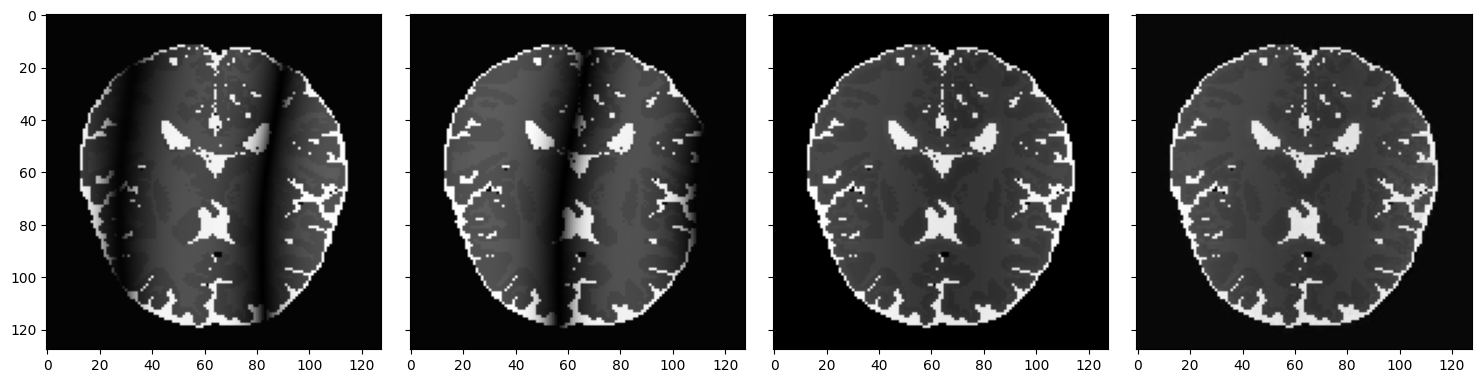

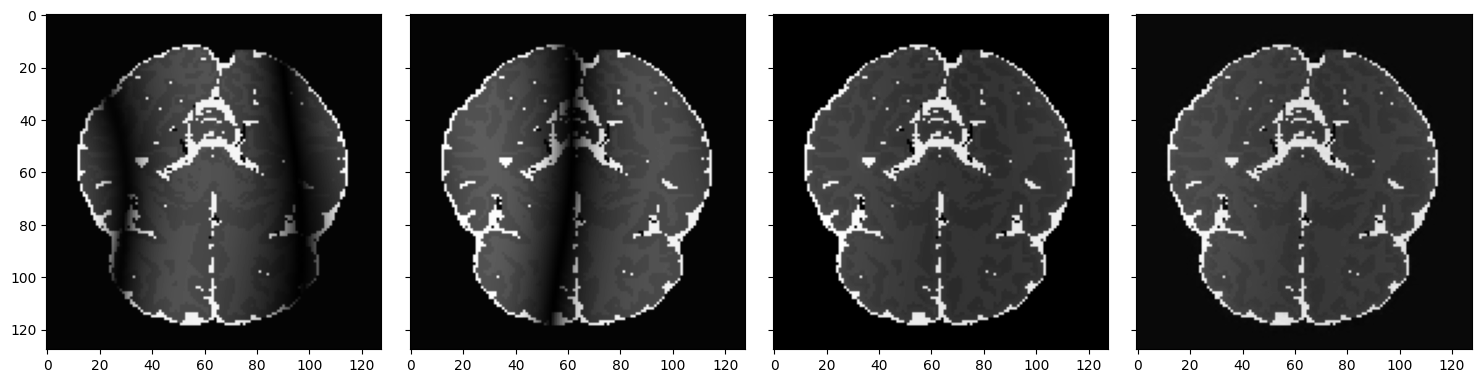

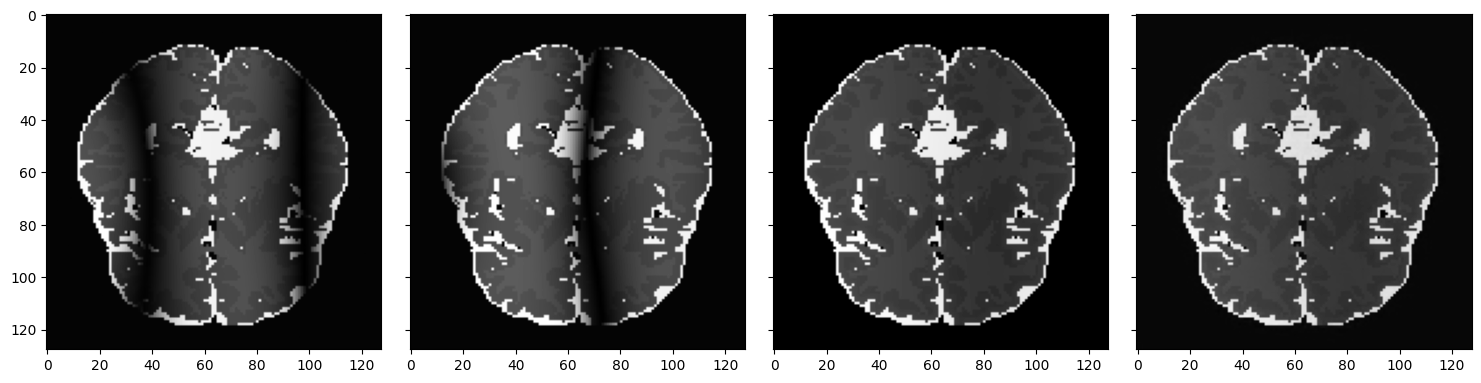

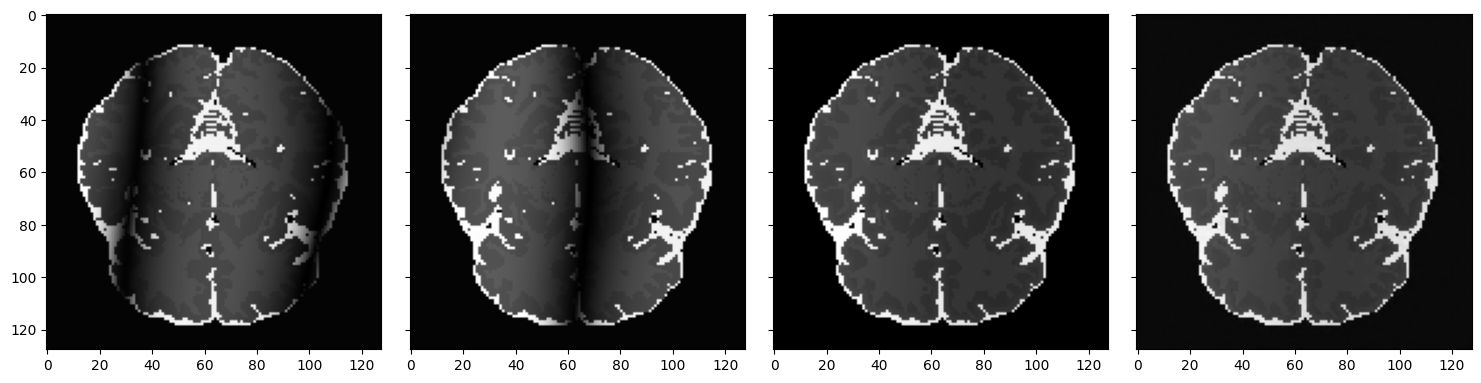

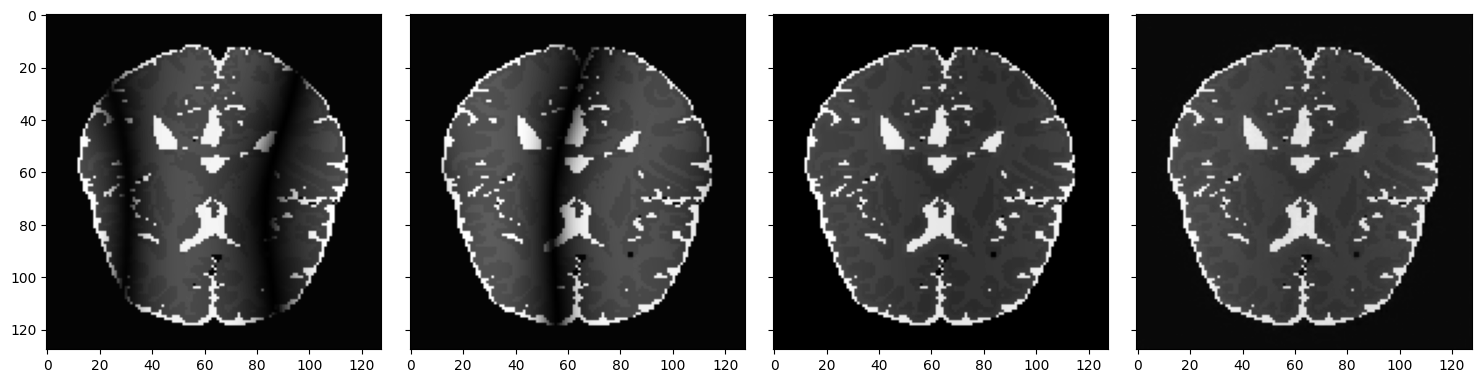

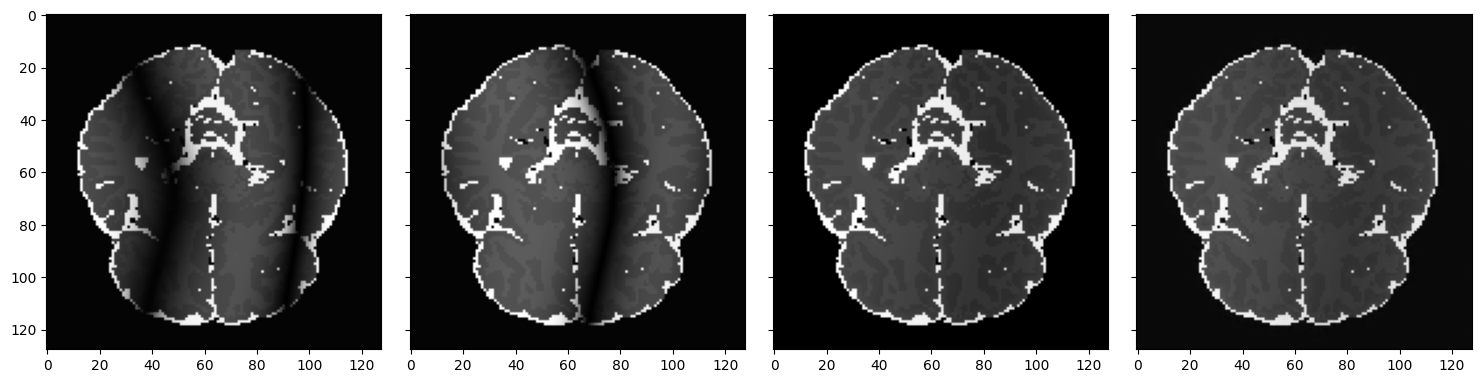

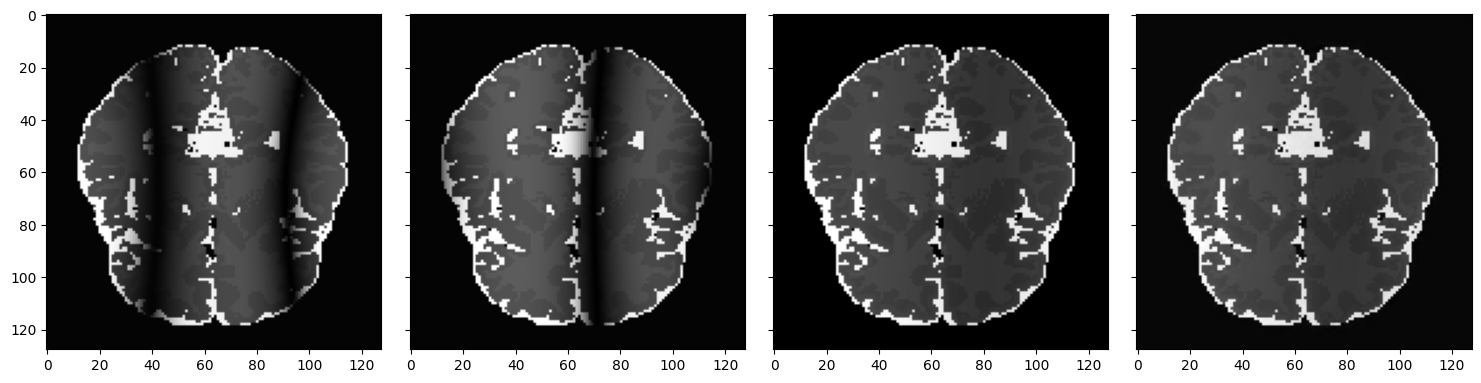

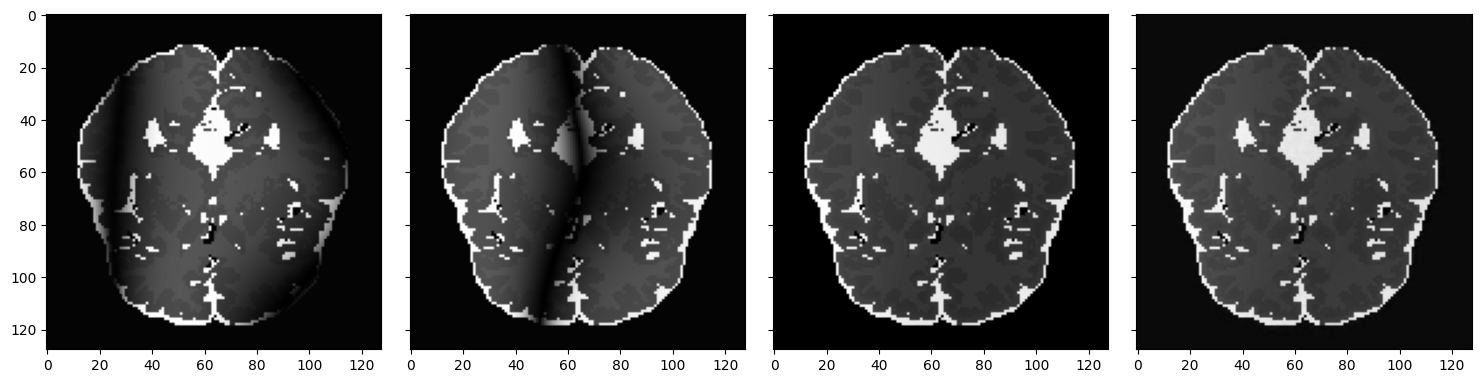

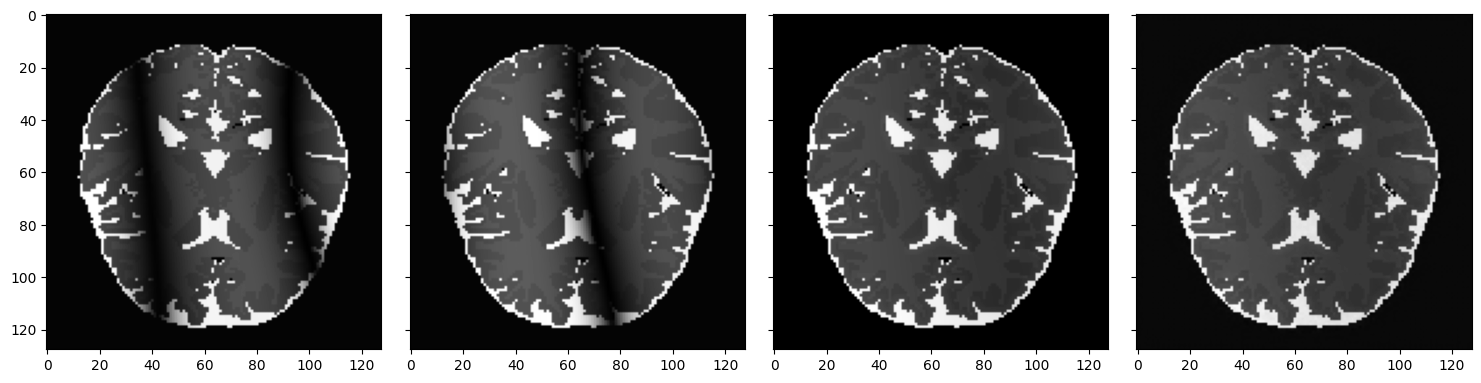

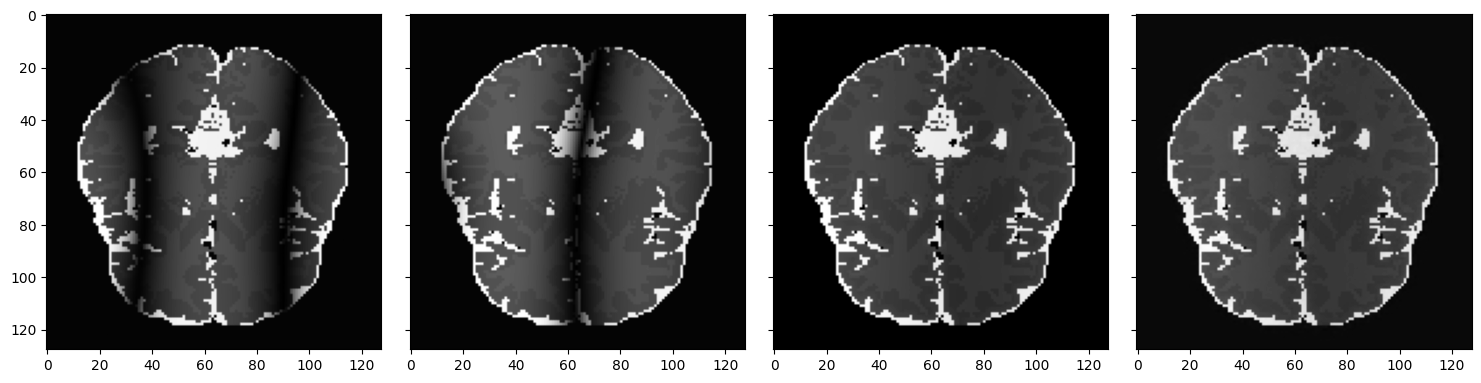

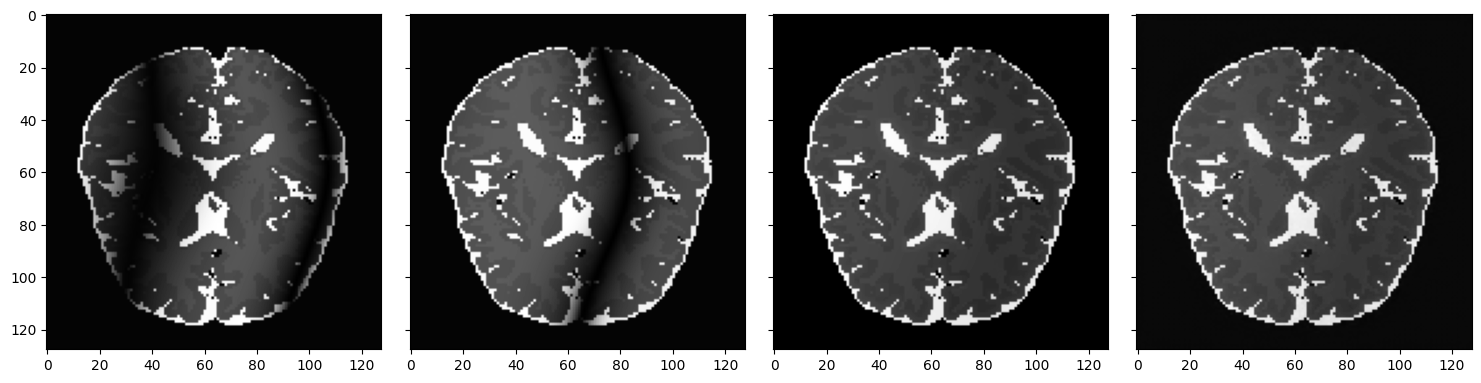

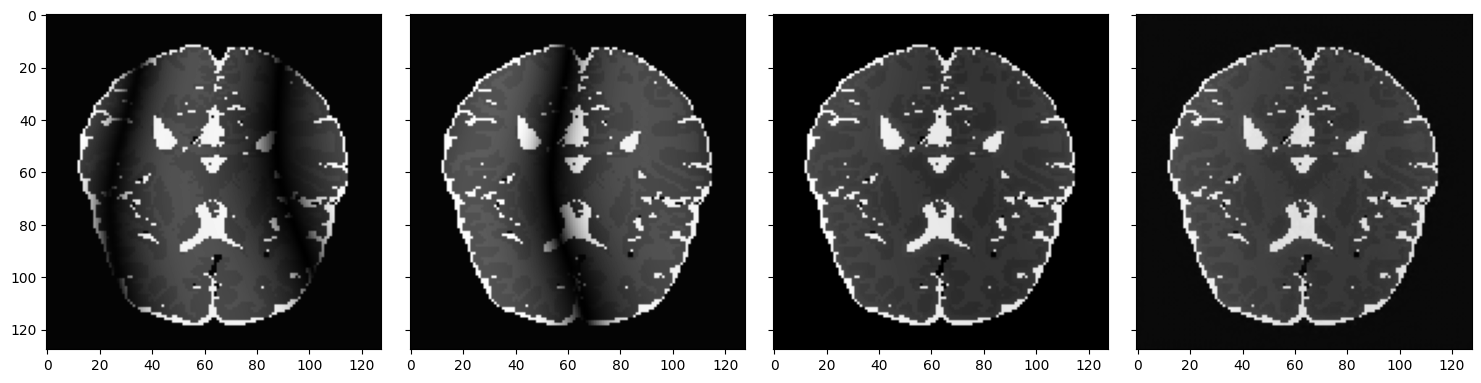

In [13]:
for i in range(24):
    plotlib.plot_model_results(i, ds.x_test, ds.y_test, predictions)